## SQLite数据库搭建与SQL基础分析

### 1. SQLite数据库建立与数据导入

In [3]:
import pandas as pd
import numpy as np
import dask.dataframe as dd
import sqlite3
import os
import pyarrow as pa
import pyarrow.parquet as pq

# 主表（文件夹，多个parquet分片）
MAIN_PARQUET = '/Users/neos/Desktop/Taobao DA/user_behavior_cleaned'

# 三张中间表
USER_PARQUET = '/Users/neos/Desktop/Taobao DA/中间表/user_agg.parquet'
ITEM_PARQUET = '/Users/neos/Desktop/Taobao DA/中间表/item_agg.parquet'
TIME_PARQUET = '/Users/neos/Desktop/Taobao DA/中间表/time_agg.parquet'

# SQLite数据库
DB_PATH = '/Users/neos/Desktop/Taobao DA/user_behavior.db'

In [4]:
# 验证主表
ddf = dd.read_parquet(MAIN_PARQUET)
print(f"主表: {ddf.shape[0].compute():,} 行, {ddf.shape[1]} 列")
print(f"主表列: {ddf.columns.tolist()}")

# 验证三张中间表
user_agg = pd.read_parquet(USER_PARQUET)
item_agg = pd.read_parquet(ITEM_PARQUET)
time_agg = pd.read_parquet(TIME_PARQUET)

print(f"\n用户表: {user_agg.shape}")
print(f"商品表: {item_agg.shape}")
print(f"时间表: {time_agg.shape}")

print(f"\n用户表列: {user_agg.columns.tolist()}")
print(f"商品表列: {item_agg.columns.tolist()}")
print(f"时间表列: {time_agg.columns.tolist()}")

主表: 6,213,379 行, 5 列
主表列: ['time', 'user_id', 'item_id', 'item_category', 'behavior_type']

用户表: (10000, 9)
商品表: (2876947, 9)
时间表: (31, 8)

用户表列: ['user_id', '总行为次数', '最早行为时间', '最晚行为时间', '活跃天数', '浏览', '收藏', '加购', '购买']
商品表列: ['item_id', '总行为次数', '最早出现时间', '最晚出现时间', '独立用户数', '浏览', '收藏', '加购', '购买']
时间表列: ['date', '总行为次数', '活跃用户数', '活跃商品数', '浏览', '收藏', '加购', '购买']


现在建立SQLite格式数据库。

In [11]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# 用户行为主表
cursor.execute('''
CREATE TABLE user_behavior (
    behavior_id INTEGER PRIMARY KEY AUTOINCREMENT,
    user_id INTEGER NOT NULL,
    item_id INTEGER NOT NULL,
    item_category INTEGER NOT NULL,
    behavior_type INTEGER NOT NULL,
    time TEXT NOT NULL
)
''')

# 用户维度表
cursor.execute('''
CREATE TABLE user_dim (
    user_id INTEGER PRIMARY KEY,
    total_behavior INTEGER,
    active_days INTEGER,
    first_time TEXT,
    last_time TEXT,
    view_count INTEGER,
    favorite_count INTEGER,
    cart_count INTEGER,
    buy_count INTEGER
)
''')

# 商品维度表
cursor.execute('''
CREATE TABLE item_dim (
    item_id INTEGER PRIMARY KEY,
    total_behavior INTEGER,
    unique_users INTEGER,
    first_time TEXT,
    last_time TEXT,
    view_count INTEGER,
    favorite_count INTEGER,
    cart_count INTEGER,
    buy_count INTEGER
)
''')

# 时间维度表
cursor.execute('''
CREATE TABLE time_dim (
    date TEXT PRIMARY KEY,
    total_behavior INTEGER,
    active_users INTEGER,
    active_items INTEGER,
    view_count INTEGER,
    favorite_count INTEGER,
    cart_count INTEGER,
    buy_count INTEGER
)
''')

conn.commit()
print("四张表重建完成")
conn.close()

四张表重建完成


In [13]:
conn = sqlite3.connect(DB_PATH)

#导入用户维度表 
user_import = user_agg.rename(columns={
    '总行为次数': 'total_behavior',
    '最早行为时间': 'first_time',
    '最晚行为时间': 'last_time',
    '活跃天数': 'active_days',
    '浏览': 'view_count',
    '收藏': 'favorite_count',
    '加购': 'cart_count',
    '购买': 'buy_count'
})
user_import = user_import[['user_id', 'total_behavior', 'active_days', 'first_time',
                            'last_time', 'view_count', 'favorite_count', 'cart_count', 'buy_count']]
user_import['first_time'] = user_import['first_time'].astype(str)
user_import['last_time'] = user_import['last_time'].astype(str)
user_import.to_sql('user_dim', conn, if_exists='append', index=False)
print(f"用户维度表导入完成: {len(user_import):,} 行")

#导入商品维度表 
item_import = item_agg.rename(columns={
    '总行为次数': 'total_behavior',
    '最早出现时间': 'first_time',
    '最晚出现时间': 'last_time',
    '独立用户数': 'unique_users',
    '浏览': 'view_count',
    '收藏': 'favorite_count',
    '加购': 'cart_count',
    '购买': 'buy_count'
})
item_import = item_import[['item_id', 'total_behavior', 'unique_users',
                            'first_time', 'last_time', 'view_count', 'favorite_count',
                            'cart_count', 'buy_count']]
item_import['first_time'] = item_import['first_time'].astype(str)
item_import['last_time'] = item_import['last_time'].astype(str)
item_import.to_sql('item_dim', conn, if_exists='append', index=False)
print(f"商品维度表导入完成: {len(item_import):,} 行")

#导入时间维度表 
time_import = time_agg.rename(columns={
    '总行为次数': 'total_behavior',
    '活跃用户数': 'active_users',
    '活跃商品数': 'active_items',
    '浏览': 'view_count',
    '收藏': 'favorite_count',
    '加购': 'cart_count',
    '购买': 'buy_count'
})
time_import = time_import[['date', 'total_behavior', 'active_users', 'active_items',
                            'view_count', 'favorite_count', 'cart_count', 'buy_count']]
time_import['date'] = time_import['date'].astype(str)
time_import.to_sql('time_dim', conn, if_exists='append', index=False)
print(f"时间维度表导入完成: {len(time_import):,} 行")

conn.commit()
conn.close()
print("\n三张维度表全部导入完成")

用户维度表导入完成: 10,000 行
商品维度表导入完成: 2,876,947 行
时间维度表导入完成: 31 行

三张维度表全部导入完成


In [14]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# 查看各表行数
for table in ['user_dim', 'item_dim', 'time_dim']:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"{table}: {cursor.fetchone()[0]:,} 行")

# 查看各表前3行
for table in ['user_dim', 'item_dim', 'time_dim']:
    print(f"\n{table} 前3行:")
    cursor.execute(f"SELECT * FROM {table} LIMIT 3")
    cols = [desc[0] for desc in cursor.description]
    print(cols)
    for row in cursor.fetchall():
        print(row)

conn.close()

user_dim: 10,000 行
item_dim: 2,876,947 行
time_dim: 31 行

user_dim 前3行:
['user_id', 'total_behavior', 'active_days', 'first_time', 'last_time', 'view_count', 'favorite_count', 'cart_count', 'buy_count']
(4913, 1026, 29, '2025-11-18 00:00:00', '2025-12-18 09:00:00', 943, 49, 29, 5)
(6118, 62, 12, '2025-11-19 12:00:00', '2025-12-18 00:00:00', 57, 4, 0, 1)
(7528, 116, 15, '2025-11-21 13:00:00', '2025-12-14 14:00:00', 86, 1, 23, 6)

item_dim 前3行:
['item_id', 'total_behavior', 'unique_users', 'first_time', 'last_time', 'view_count', 'favorite_count', 'cart_count', 'buy_count']
(64, 1, 1, '2025-11-30 23:00:00', '2025-11-30 23:00:00', 1, 0, 0, 0)
(496, 1, 1, '2025-12-02 16:00:00', '2025-12-02 16:00:00', 1, 0, 0, 0)
(528, 1, 1, '2025-11-24 09:00:00', '2025-11-24 09:00:00', 1, 0, 0, 0)

time_dim 前3行:
['date', 'total_behavior', 'active_users', 'active_items', 'view_count', 'favorite_count', 'cart_count', 'buy_count']
('2025-12-06', 198378, 6440, 150061, 176579, 8279, 10614, 2906)
('2025-12-18', 1

In [15]:
# 主表分批写入SQLite
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# 使用with自动管理commit
with conn:
    cursor.execute("DELETE FROM user_behavior")  # 清空，避免重复运行

# 分批导入
total = 0
npartitions = ddf.npartitions
print(f"主表总分区数: {npartitions}")

for i, partition in enumerate(ddf.partitions):
    chunk = partition.compute()
    chunk = chunk[['user_id', 'item_id', 'item_category', 'behavior_type', 'time']]
    chunk['time'] = chunk['time'].astype(str)
    
    chunk.to_sql('user_behavior', conn, if_exists='append', index=False)
    total += len(chunk)
    print(f"已导入分区 {i+1}/{npartitions}, 累计 {total:,} 行")

conn.commit()
conn.close()
print(f"\n主表导入完成，共 {total:,} 行")

主表总分区数: 3
已导入分区 1/3, 累计 2,071,535 行
已导入分区 2/3, 累计 4,141,315 行
已导入分区 3/3, 累计 6,213,379 行

主表导入完成，共 6,213,379 行


In [17]:
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# 主表行数
cursor.execute("SELECT COUNT(*) FROM user_behavior")
print(f"主表行数: {cursor.fetchone()[0]:,}")

# 主表前3行
print("\n主表前3行:")
cursor.execute("SELECT * FROM user_behavior LIMIT 3")
cols = [desc[0] for desc in cursor.description]
print(cols)
for row in cursor.fetchall():
    print(row)

conn.close()


主表行数: 6,213,379

主表前3行:
['behavior_id', 'user_id', 'item_id', 'item_category', 'behavior_type', 'time']
(1, 98047837, 232431562, 4245, 1, '2025-12-06 02:00:00')
(2, 98607707, 64749712, 2883, 1, '2025-12-18 11:00:00')
(3, 104221274, 262661866, 4370, 1, '2025-12-14 12:00:00')


### 2. 基础统计分析

In [18]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(DB_PATH)

# 确认能查到数据
pd.read_sql("SELECT COUNT(*) AS 总行为数 FROM user_behavior", conn)

,总行为数
0,6213379


In [ ]:
用户行为总量统计

In [19]:
sql_total = """
SELECT 
    COUNT(*) AS 总行为数,
    COUNT(DISTINCT user_id) AS 总用户数,
    COUNT(DISTINCT item_id) AS 总商品数,
    COUNT(DISTINCT item_category) AS 总类目数,
    MIN(time) AS 最早时间,
    MAX(time) AS 最晚时间
FROM user_behavior
"""
result = pd.read_sql(sql_total, conn)
print("用户行为总量统计:")
print(result.T)

用户行为总量统计:
                        0
总行为数              6213379
总用户数                10000
总商品数              2876947
总类目数                 8916
最早时间  2025-11-18 00:00:00
最晚时间  2025-12-18 23:00:00


本次用于研究的数据为：
用户数：10000
商品数：2876947
商品类目数：8916
时间：2025年11月18日-12月18日，维期一个月


各行为类型占比
其中浏览占大多数。达到89.1%。其他三种行为中，加购占比5.33%，其次是浏览占比3.85%，购买最低，仅1.72%。

In [20]:
sql_behavior = """
SELECT 
    behavior_type,
    CASE behavior_type
        WHEN 1 THEN '浏览'
        WHEN 2 THEN '收藏'
        WHEN 3 THEN '加购'
        WHEN 4 THEN '购买'
    END AS 行为名称,
    COUNT(*) AS 行为次数,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM user_behavior), 2) AS 占比百分比
FROM user_behavior
GROUP BY behavior_type
ORDER BY behavior_type
"""
behavior_result = pd.read_sql(sql_behavior, conn)
print("各行为类型占比:")
print(behavior_result)

各行为类型占比:
   behavior_type 行为名称     行为次数  占比百分比
0              1   浏览  5535879  89.10
1              2   收藏   239472   3.85
2              3   加购   331350   5.33
3              4   购买   106678   1.72


日活/周活趋势（当日）
当日有任何行为都计算入活跃用户。通过图像可以看到日活整体在波动中上升，在12月12日出现高峰，可能是由于双十二活动。

周活以自然周进行计算，且对用户进行去重，只统计有多少用户当周有活跃行为。

In [21]:
#日活趋势 
sql_dau = """
SELECT 
    date AS 日期,
    active_users AS 日活用户数,
    total_behavior AS 当日总行为数
FROM time_dim
ORDER BY date
"""
dau_result = pd.read_sql(sql_dau, conn)
print("日活趋势:")
print(dau_result)

日活趋势:
            日期  日活用户数  当日总行为数
0   2025-11-18   6343  186278
1   2025-11-19   6420  181713
2   2025-11-20   6333  178849
3   2025-11-21   6276  168903
4   2025-11-22   6187  183014
5   2025-11-23   6373  194205
6   2025-11-24   6513  191139
7   2025-11-25   6351  186803
8   2025-11-26   6357  183017
9   2025-11-27   6359  188747
10  2025-11-28   6189  172392
11  2025-11-29   6224  185940
12  2025-11-30   6379  204398
13  2025-12-01   6544  200520
14  2025-12-02   6550  206313
15  2025-12-03   6585  209477
16  2025-12-04   6531  203829
17  2025-12-05   6367  183633
18  2025-12-06   6440  198378
19  2025-12-07   6422  202206
20  2025-12-08   6564  197172
21  2025-12-09   6566  202261
22  2025-12-10   6652  215171
23  2025-12-11   6894  247364
24  2025-12-12   7720  346464
25  2025-12-13   6776  205983
26  2025-12-14   6668  204056
27  2025-12-15   6787  201242
28  2025-12-16   6729  199749
29  2025-12-17   6643  193980
30  2025-12-18   6582  190183


In [22]:
# 周活趋势（去重）
sql_wau_accurate = """
SELECT 
    STRFTIME('%Y-%W', time) AS 年份_周数,
    MIN(DATE(time)) AS 周起始日期,
    MAX(DATE(time)) AS 周结束日期,
    COUNT(DISTINCT user_id) AS 周活用户数,
    COUNT(*) AS 周总行为数
FROM user_behavior
GROUP BY STRFTIME('%Y-%W', time)
ORDER BY 年份_周数
"""
wau_accurate = pd.read_sql(sql_wau_accurate, conn)
print("\n周活趋势（准确版，去重）:")
print(wau_accurate)


周活趋势（准确版，去重）:
     年份_周数       周起始日期       周结束日期  周活用户数    周总行为数
0  2025-46  2025-11-18  2025-11-23   8964  1092962
1  2025-47  2025-11-24  2025-11-30   9224  1312436
2  2025-48  2025-12-01  2025-12-07   9354  1404356
3  2025-49  2025-12-08  2025-12-14   9506  1618471
4  2025-50  2025-12-15  2025-12-18   8947   785154


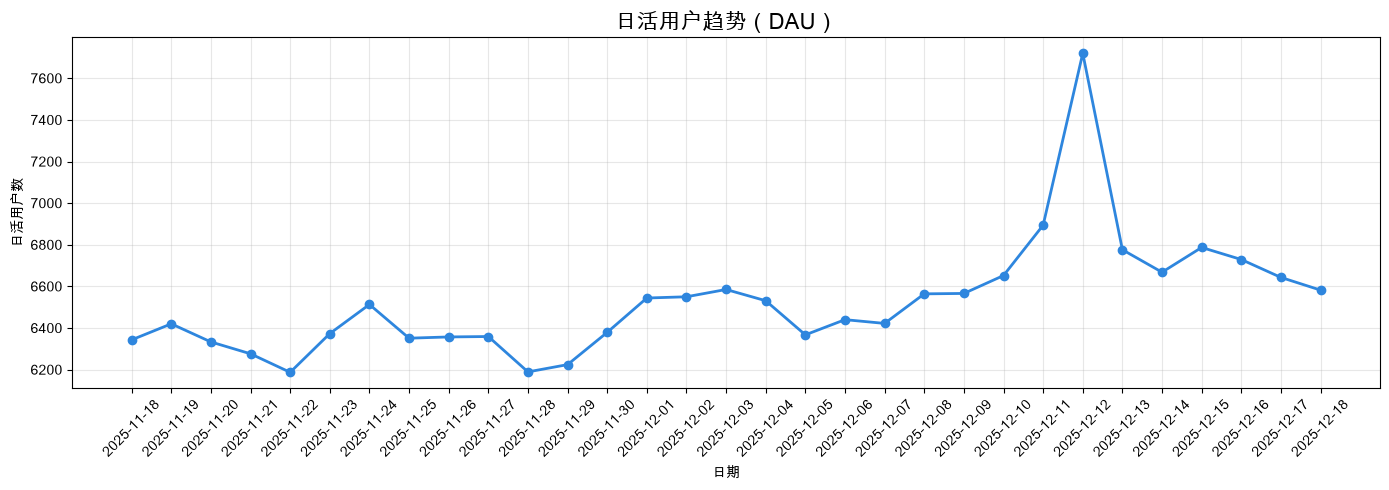

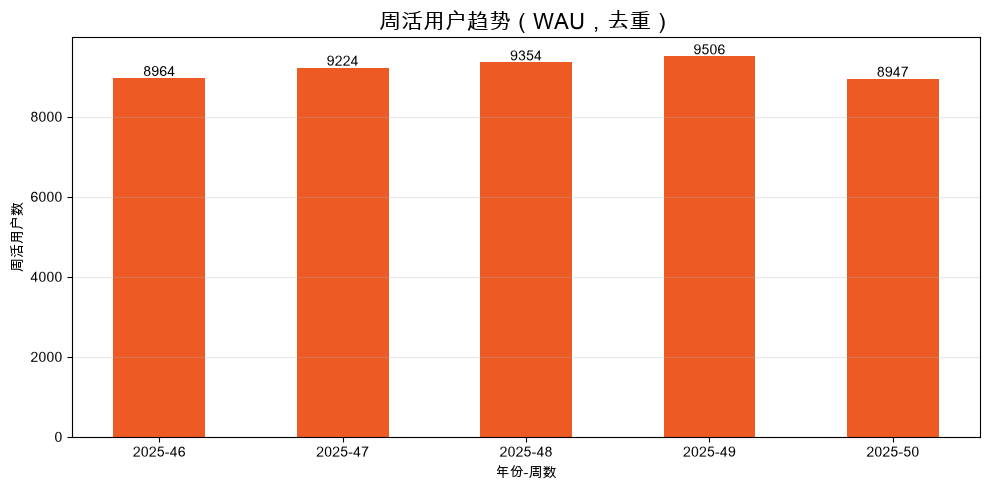

In [23]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 日活
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dau_result['日期'], dau_result['日活用户数'], marker='o', linewidth=2, color='#2E86DE')
ax.set_title('日活用户趋势（DAU）', fontsize=16)
ax.set_xlabel('日期')
ax.set_ylabel('日活用户数')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#周活趋势图（去重）
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(wau_accurate['年份_周数'].astype(str), wau_accurate['周活用户数'], 
       color='#EE5A24', width=0.5)
ax.set_title('周活用户趋势（WAU，去重）', fontsize=16)
ax.set_xlabel('年份-周数')
ax.set_ylabel('周活用户数')
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(wau_accurate['周活用户数']):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

热门商品与类目排名，按总行为次数排名，计算前20名：

In [24]:
#热门商品排名 Top 20（按总行为次数）
sql_hot_item = """
SELECT 
    item_id AS 商品ID,
    total_behavior AS 总行为次数,
    unique_users AS 独立用户数,
    view_count AS 浏览次数,
    favorite_count AS 收藏次数,
    cart_count AS 加购次数,
    buy_count AS 购买次数
FROM item_dim
ORDER BY total_behavior DESC
LIMIT 20
"""
hot_item = pd.read_sql(sql_hot_item, conn)
print("热门商品 Top 20:")
print(hot_item)

热门商品 Top 20:
         商品ID  总行为次数  独立用户数  浏览次数  收藏次数  加购次数  购买次数
0   112921337    730    518   716     5     8     1
1    97655171    589    332   550     7    19    13
2   387911330    519    298   473    10    17    19
3   135104537    493    339   478     7     8     0
4     2217535    425    317   412     1    11     1
5   128186279    423    341   395    13    14     1
6     5685392    403    302   377    12    12     2
7   277922302    401    275   356    24    20     1
8   275450912    389    288   382     5     2     0
9    14087919    375    206   300    15    33    27
10  209323160    360    282   332     2    26     0
11  374235261    345    300   334     5     5     1
12  353381230    325    193   281     9    30     5
13  211781109    300    177   266    14    19     1
14  303205878    299    163   229     9    41    20
15  361681874    292    249   268     5    15     4
16    6703599    288    186   254    17    15     2
17   21087251    288    217   264    12    10     2

In [25]:
#  热门类目排名 Top 20（按总行为次数）
sql_hot_category = """
SELECT 
    item_category AS 类目ID,
    COUNT(*) AS 总行为次数,
    COUNT(DISTINCT item_id) AS 商品数,
    COUNT(DISTINCT user_id) AS 独立用户数,
    SUM(CASE WHEN behavior_type = 1 THEN 1 ELSE 0 END) AS 浏览次数,
    SUM(CASE WHEN behavior_type = 2 THEN 1 ELSE 0 END) AS 收藏次数,
    SUM(CASE WHEN behavior_type = 3 THEN 1 ELSE 0 END) AS 加购次数,
    SUM(CASE WHEN behavior_type = 4 THEN 1 ELSE 0 END) AS 购买次数
FROM user_behavior
GROUP BY item_category
ORDER BY 总行为次数 DESC
LIMIT 20
"""
hot_category = pd.read_sql(sql_hot_category, conn)
print("\n热门类目 Top 20:")
print(hot_category)


热门类目 Top 20:
     类目ID   总行为次数    商品数  独立用户数    浏览次数   收藏次数  加购次数  购买次数
0    1863  201110  83354   5997  179997  10094  9109  1910
1   13230  177948  74067   5619  164124   7128  5871   825
2    5894  169451  83758   5279  154282   7775  6467   927
3    5027  168103  60323   5499  154926   6903  5459   815
4    6513  152148  65045   5288  138039   6619  6486  1004
5    5399  141726  54559   5312  128875   6528  5309  1014
6   11279   94686  47538   4715   85763   4618  3602   703
7    2825   84911  43997   4551   77427   3325  3581   578
8    5232   71772  25900   4972   63480   2564  4344  1384
9   10894   71129  33482   4523   63782   2767  3769   811
10   4370   63009  30437   4518   56526   2449  3317   717
11   5689   59193  30631   4053   53004   2872  2789   528
12   3064   58085  16562   1991   50640   2925  3796   724
13   6000   52627  14204   4594   50229    869  1233   296
14  14079   50257  24376   3592   45154   2176  2466   461
15  10392   49751  21316   3832   44357   

### 3. 转化漏斗分析

In [27]:
# ========== 1. 每个用户的行为条数分布 ==========
sql_dist = """
SELECT 
    MIN(cnt) AS 最少行为数,
    MAX(cnt) AS 最多行为数,
    AVG(cnt) AS 平均行为数,
    COUNT(*) AS 用户数
FROM (
    SELECT user_id, COUNT(*) AS cnt
    FROM user_behavior
    GROUP BY user_id
)
"""
print("用户行为条数分布:")
print(pd.read_sql(sql_dist, conn))

用户行为条数分布:
   最少行为数  最多行为数     平均行为数    用户数
0      1  15936  621.3379  10000


转化漏斗计算。此处定义同一用户必须先浏览、再收藏、再加购、最后购买，逐级筛选。

In [31]:
sql_funnel_strict = """
WITH 
browse_users AS (
    SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type = 1
),
favorite_users AS (
    SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type = 2
),
cart_users AS (
    SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type = 3
),
buy_users AS (
    SELECT DISTINCT user_id FROM user_behavior WHERE behavior_type = 4
)
SELECT 
    (SELECT COUNT(*) FROM browse_users) AS 浏览用户数,
    (SELECT COUNT(*) FROM browse_users 
     WHERE user_id IN (SELECT user_id FROM favorite_users)) AS 浏览且收藏,
    (SELECT COUNT(*) FROM browse_users 
     WHERE user_id IN (SELECT user_id FROM favorite_users)
       AND user_id IN (SELECT user_id FROM cart_users)) AS 浏览且收藏且加购,
    (SELECT COUNT(*) FROM browse_users 
     WHERE user_id IN (SELECT user_id FROM favorite_users)
       AND user_id IN (SELECT user_id FROM cart_users)
       AND user_id IN (SELECT user_id FROM buy_users)) AS 完整转化
"""
funnel_strict = pd.read_sql(sql_funnel_strict, conn)
print("严格转化漏斗:")
print(funnel_strict.T)

严格转化漏斗:
              0
浏览用户数     10000
浏览且收藏      6730
浏览且收藏且加购   6020
完整转化       5739


In [ ]:
将用户按活跃度类型进行分群统计。首先查看用户行为分布，根据统计数据将用户分为三类：
低活用户：行为次数 ≤ 372（中位数以下，50%）
中活用户：372 < 行为次数 ≤ 1474（50%~90%，40%）
高活用户：行为次数 > 1474（90%以上，10%）

然后进行统计，发现高活跃度用户仅占不到10%，低活跃度用户占比一半，其次是中活跃度用户占比达到40%。

In [33]:
sql_user_activity = """
SELECT 
    user_id,
    COUNT(*) AS 总行为次数
FROM user_behavior
GROUP BY user_id
"""
user_activity = pd.read_sql(sql_user_activity, conn)

print("用户行为次数分布:")
print(user_activity['总行为次数'].describe())
print("\n分位数:")
for q in [0.25, 0.5, 0.75, 0.9, 0.95]:
    print(f"  {int(q*100)}%分位: {user_activity['总行为次数'].quantile(q):.0f}")

用户行为次数分布:
count    10000.000000
mean       621.337900
std        788.498887
min          1.000000
25%        158.000000
50%        372.000000
75%        783.000000
max      15936.000000
Name: 总行为次数, dtype: float64

分位数:
  25%分位: 158
  50%分位: 372
  75%分位: 783
  90%分位: 1474
  95%分位: 2040


In [34]:
sql_activity_segment = """
WITH user_activity AS (
    SELECT 
        user_id,
        COUNT(*) AS total_behavior
    FROM user_behavior
    GROUP BY user_id
),
user_segment AS (
    SELECT 
        user_id,
        total_behavior,
        CASE 
            WHEN total_behavior <= 372 THEN '低活用户'
            WHEN total_behavior <= 1474 THEN '中活用户'
            ELSE '高活用户'
        END AS 活跃度分群
    FROM user_activity
)
SELECT 
    活跃度分群,
    COUNT(*) AS 用户数,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM user_segment), 2) AS 占比百分比,
    ROUND(AVG(total_behavior), 1) AS 平均行为次数,
    MIN(total_behavior) AS 最少行为次数,
    MAX(total_behavior) AS 最多行为次数
FROM user_segment
GROUP BY 活跃度分群
ORDER BY 平均行为次数 DESC
"""
activity_result = pd.read_sql(sql_activity_segment, conn)
print("用户活跃度分群统计:")
print(activity_result)

用户活跃度分群统计:
  活跃度分群   用户数  占比百分比  平均行为次数  最少行为次数  最多行为次数
0  高活用户   999   9.99  2422.8    1475   15936
1  中活用户  4000  40.00   738.8     373    1474
2  低活用户  5001  50.01   167.5       1     372


In [ ]:
商品复购率。复购定义：同一用户对同一商品购买超过一次算复购。计算标准：商品复购率 = 该商品有复购的用户数 / 购买过该商品的用户数
分析得复购率仅为2.96%，较低，可以在后续分析中进一步研究。

In [35]:
sql_repurchase_base = """
SELECT 
    item_id,
    user_id,
    COUNT(*) AS buy_times
FROM user_behavior
WHERE behavior_type = 4
GROUP BY item_id, user_id
"""
repurchase_base = pd.read_sql(sql_repurchase_base, conn)

print(f"用户-商品购买记录数: {len(repurchase_base):,}")
print(f"\n购买次数分布:")
print(repurchase_base['buy_times'].value_counts().sort_index().head(10))

# 复购（购买≥2次）的记录数
repurchase_count = (repurchase_base['buy_times'] >= 2).sum()
print(f"\n复购记录数（购买≥2次）: {repurchase_count:,}")
print(f"复购占比: {repurchase_count/len(repurchase_base)*100:.2f}%")

用户-商品购买记录数: 102,996

购买次数分布:
buy_times
1     99947
2      2645
3       281
4        82
5        17
6        12
7         2
8         2
9         3
10        3
Name: count, dtype: int64

复购记录数（购买≥2次）: 3,049
复购占比: 2.96%
